In [ ]:
# --- SETUP ---
import os
import csv
import math
import random
from tqdm import tqdm

from astropy.io import fits
from astropy.io.fits import getdata
from google.colab import drive
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from astropy.wcs import WCS
import re
import scipy as sp
from IPython.display import clear_output # Import the clear_output function
from astropy.nddata import Cutout2D
from astropy.coordinates import SkyCoord
import astropy.units as u

from PIL import Image, ImageDraw
from shapely.geometry import Point
from shapely.ops import unary_union
from shapely.geometry.polygon import Polygon

import cv2

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# --- DEFINE CONSTANT VALUES ---

const_vmin = 0.1
const_vmax = 0.8
const_cmap = "gray"
MAX_TRIES = 200000
SAFETY_MARGIN_PIX = 5                             # avoid edges of bubbles

# Getting the image of the NGC-628 galaxy from MAST data
fits_path = '/content/drive/MyDrive/thesisDocuments/jw01783-o908_t016_miri_f560w_i2d.fits'
catalogue_path = "/content/drive/MyDrive/thesisDocuments/jwst_bubble_properties_A.txt"
bubble_output_path = '/content/drive/MyDrive/thesisDocuments/bubblesIteration2/bubble_images'
nonbubble_output_path = '/content/drive/MyDrive/thesisDocuments/bubblesIteration2/non-bubble_images'
out_bubblemask = '/content/drive/MyDrive/thesisDocuments/ngc628_data/bubble_mask'
root_output_path = '/content/drive/MyDrive/thesisDocuments/bubblesIteration2/'
mask_output_path = '/content/drive/MyDrive/thesisDocuments/bubblemaskdataset'
root_path = '/content/drive/MyDrive/thesisDocuments'

os.makedirs(bubble_output_path, exist_ok=True)
os.makedirs(nonbubble_output_path, exist_ok=True)
os.makedirs(out_bubblemask, exist_ok=True)
os.makedirs(root_output_path, exist_ok=True)
os.makedirs(mask_output_path, exist_ok=True)
os.makedirs(root_path, exist_ok=True)

# Distance to NGC 628 (M74) in Mpc
DIST_MPC = 9.84   # ~9.84 Mpc (PHANGS value, you can update)
PC_PER_ARCSEC = DIST_MPC * 1e6 * np.tan(np.deg2rad(1/3600))  # physical scale pc/arcsec

print(f"Scale: {PC_PER_ARCSEC:.2f} pc/arcsec")



Scale: 47.71 pc/arcsec


In [ ]:
# --- Coordinate Utilities ---

def get_coord(ra_str, dec_str, unit=None):
  # Parse RA and Dec strings to extract degrees, minutes, and seconds
  ra_match = re.match(r'(\d+)d(\d+)m([\d.]+?)s', ra_str)
  dec_match = re.match(r'(\d+)d(\d+)m([\d.]+?)s', dec_str)

  if ra_match and dec_match:
      ra_deg = int(ra_match.group(1)) + int(ra_match.group(2))/60 + float(ra_match.group(3))/3600
      dec_deg = int(dec_match.group(1)) + int(dec_match.group(2))/60 + float(dec_match.group(3))/3600
      c = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg)
  elif unit:
    c = SkyCoord(ra_str, dec_str, unit)
  else:
    c = SkyCoord(ra_str, dec_str, unit=(u.hourangle, u.deg))  # if RA is in hms, Dec in dms
  return c


# Convert average radius in pc -> arcsec -> pixels
def pc_to_px(avg_pc, wcs):
  size_arcsec = avg_pc / PC_PER_ARCSEC
  pix_scale = np.abs(wcs.pixel_scale_matrix).mean() * 3600        # arcsec/pixel
  size_pix = int(2 * size_arcsec / pix_scale)                    # diameter in pixels

  # if size_pix < 8:
  #     size_pix = 8  # minimum cutout size

  return size_pix


def pixel_to_skycoord(x, y, wcs):
  return wcs.pixel_to_world(x, y)


def sample_nonbubble_centers(image_shape, bubble_regions, min_radius_px, max_radius_px, limit=1600):
  coords = []
  h, w = image_shape

  while len(coords) < limit:
    # Random point in image
    x = np.random.randint(max_radius_px, w - max_radius_px)
    y = np.random.randint(max_radius_px, h - max_radius_px)

    # Random radius in range
    r = np.random.randint(min_radius_px, max_radius_px)

    # Check against bubble regions (avoid overlap)
    safe = True
    for region in bubble_regions:
      cx, cy = region["center"]
      cr = region["radius"]
      if np.hypot(x - cx, y - cy) < (r + cr):
        safe = False
        break

    if safe:
      coords.append((x, y, r))

  return coords


In [ ]:
#  --- Image Processing ---

def normalize_stamp(stamp, method="asinh"):
  if np.all(np.isnan(stamp)):
    return np.zeros_like(stamp, dtype=np.float32)

  s = np.nan_to_num(stamp, nan=0.0)

  if method == "minmax":
    s -= np.nanmin(s)
    maxv = np.nanmax(s)
    if maxv > 0:
        s /= maxv
    return s.astype(np.float32)

  elif method == "asinh":
    p_lo, p_hi = np.nanpercentile(s, (1, 99.5))
    s = np.clip(s - p_lo, 0, None)
    scale = max(1e-6, (p_hi - p_lo) / 10.0)
    stretched = np.arcsinh(s/scale) / np.arcsinh((p_hi-p_lo)/scale)
    return np.clip(stretched, 0, 1).astype(np.float32)


def make_cutout(image_data, wcs, ra_str, dec_str, radius_pc):
  coord = get_coord(ra_str, dec_str)

  # Convert radius from pc -> pixels
  size_pix = pc_to_px(radius_pc, wcs)
  try:
    print("value of wcs in make_cutout: ", wcs)
    cutout = Cutout2D(image_data, coord, (size_pix, size_pix), wcs=wcs)
    return cutout
  except Exception as e:
    print(f"Error creating cutout at RA: {ra_str}, Dec: {dec_str} with radius {radius_pc} pc: {e}")
    return None


In [ ]:
#  --- Plotting ---

def plot_cutout(cutout, bubble_row, save=None):
  fig, ax = plt.subplots(1, 1, figsize=(5, 5), dpi=150, subplot_kw={'projection': cutout.wcs})

  norm_stamp = normalize_stamp(cutout.data)
  ax.imshow(norm_stamp, origin="lower", cmap=const_cmap)
  ax.set_title(f"Bubble {bubble_row['ID']}")

  if save:
    save_files(bubble_row["ID"], path=save)

  plt.show()


def save_cutout(cutout, fname):
  norm_stamp = normalize_stamp(cutout.data)
  plt.imsave(fname, norm_stamp, cmap=const_cmap)


# An extra function for a sanity check on - visualization of bubble and non-bubble regions on the galaxy image
def plot_regions_on_galaxy(image_data, wcs, bubble_regions=None, nonbubble_regions=None, save=None):
    fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': wcs})
    norm_stamp = normalize_stamp(image_data)
    ax.imshow(norm_stamp, origin="lower", cmap=const_cmap, vmin=const_vmin, vmax=const_vmax)

    # Plot bubbles in yellow
    if bubble_regions:
        for reg in bubble_regions:
            cx, cy = reg["center"]
            circ = plt.Circle((cx, cy), reg["radius"], edgecolor="yellow", facecolor="none", lw=1.5, alpha=0.8)
            ax.add_patch(circ)

    # Plot non-bubbles in red
    if nonbubble_regions:
        for reg in nonbubble_regions:
            cx, cy = reg["center"]
            circ = plt.Circle((cx, cy), reg["radius"], edgecolor="red", facecolor="none", lw=1.5, alpha=0.8)
            ax.add_patch(circ)

    ax.set_title("Bubble (yellow) vs Non-Bubble (red) Regions")
    ax.set_xlabel("RA")
    ax.set_ylabel("Dec")

    if save:
        plt.savefig(save, dpi=200)
        plt.close(fig)
    else:
        plt.show()


def generate_non_bubble_cutouts(image_data, wcs, df, save, limit=1600, min_radius_pc=20):
    # Build bubble mask
    bubble_regions = make_bubble_mask(df, wcs, image_data.shape)

    # Match number of non-bubbles to bubbles
    limit = len(df) if limit is None else min(limit, len(df))

    # Convert pc → px for crop sizes
    min_radius_px = pc_to_px(min_radius_pc, wcs)
    max_radius_px = df["AVG_RAD_PC"].max()
    max_radius_px = pc_to_px(max_radius_px, wcs)

    # Sample candidate centers
    coords = sample_nonbubble_centers(image_data.shape, bubble_regions, min_radius_px, max_radius_px, limit)
    nonbubble_regions = [{"center": (x, y), "radius": r} for x, y, r in coords]

    # Plot both
    plot_regions_on_galaxy(image_data, wcs, bubble_regions, nonbubble_regions, save=root_output_path)

    # Save cutouts + metadata
    rows = []
    for i, (x, y, r) in enumerate(coords):
        cutout = Cutout2D(image_data, (x, y), (2*r, 2*r), wcs=wcs)
        norm_stamp = normalize_stamp(cutout.data)

        fname = os.path.join(save, f"nonbubble_{i}.jpg")
        plt.imsave(fname, norm_stamp, cmap=const_cmap)

        # Convert to RA/DEC
        sky = pixel_to_skycoord(x, y, wcs)

        rows.append({
            "ID": i,
            "RA_DMS": sky.ra.to_string(unit=u.hour, sep='hms'),
            "DEC_DMS": sky.dec.to_string(unit=u.deg, sep='dms'),
            "AVG_RAD_PC": r * PC_PER_ARCSEC  # back to pc
        })

    # Save metadata txt file (like bubble catalogue)
    df_out = pd.DataFrame(rows)
    df_out.to_csv(os.path.join(save, "nonbubble_catalogue.txt"), index=False)
    return df_out


In [ ]:
#  --- Preprocessing ---

def adjust_shifted_radius(df, col="AVG_RAD_PC"):
  df_fixed = df.copy()
  df_fixed[col] = df[col].shift(-1)   # shift upwards
  return df_fixed


def filter_small_bubbles(df, min_radius_pc=20, col="AVG_RAD_PC"):
  df_filtered = df[df[col] >= min_radius_pc].reset_index(drop=True)
  print(f"Filtered out {len(df) - len(df_filtered)} bubbles (radius < {min_radius_pc} pc)")
  return df_filtered


def adjust_and_filter(df, adjusting_shift_error=False, is_filtering=None):
  if adjusting_shift_error:
    df = adjust_shifted_radius(df)
  if is_filtering:
    df = filter_small_bubbles(df, is_filtering)
  return df


In [ ]:
# --- TOOLS ---

def make_bubble_mask(df, wcs, image_shape):
  regions = []
  for _, row in df.iterrows():
    coord = get_coord(row['RA_DMS'], row['DEC_DMS'], unit=(u.deg, u.deg))
    x, y = wcs.world_to_pixel(coord)

    regions.append({
        "center": (x, y),
        "radius": pc_to_px(row["AVG_RAD_PC"], wcs)
    })

  return regions

In [ ]:
# --- I/O utilities ---

def load_galaxy_image(path):
  hdul = fits.open(path)

  image_data = hdul[1].data
  w = WCS(hdul[1].header)     # WCS is object of astropy.wcs

  print(type(image_data))
  print(image_data.shape)

  image = plt.imshow(image_data, vmin=const_vmin, vmax=const_vmax, cmap=const_cmap)
  plt.colorbar()

  return image_data, w


def load_catalogue(path):
  df = pd.read_csv(path)

  print(df.head())
  print(df.columns)
  print(df.shape)

  return df


def save_files(bubble_name, file_type='.jpg', path=bubble_output_path):
  file_data = os.path.join(path, f"bubble_{bubble_name}{file_type}")
  plt.savefig(file_data)

In [ ]:
def build_bubble_dataset(image_data, wcs, df, limit=None, save=None):
  for i, row in df.head(limit).iterrows():
    try:
      print("value of wcs in build_bubble_dataset: ", wcs)
      cutout = make_cutout(image_data, wcs, row["RA_DMS"], row["DEC_DMS"], row["AVG_RAD_PC"])
      plot_cutout(cutout, row, save)

    except Exception as e:
      print(f"Skipping bubble {row['ID']} due to error: {e}")


def build_nonbubble_dataset(image_data, wcs, df, limit=None, save=None):
  generate_non_bubble_cutouts(image_data, wcs, df, save=save, limit=limit)


def build_bubble_mask(image_data, wcs, df, save=out_bubblemask):
  _, mask = make_bubble_mask(df, wcs, image_data.shape, is_binary=True)
  plt.imshow(mask, cmap='gray')
  # plt.savefig(save)
  save_files("ngc628_binarymask", file_type='.jpg', path=out_bubblemask)



In [ ]:
def build_datasets(fits_path, catalogue_path, out_bubbles=None, out_nonbubbles=None, out_bubblemask=None, fix_radius=False, filter_small_bubbles=20, limit=None):
  # Load data
  image_data, wcs = load_galaxy_image(fits_path)
  df = load_catalogue(catalogue_path)

  # Clean catalogue
  adjust_and_filter(df, adjusting_shift_error=fix_radius, is_filtering=filter_small_bubbles)

  # Bubble dataset
  if out_bubbles:
    build_bubble_dataset(image_data, wcs, df, limit=limit, save=out_bubbles)

  # Non-bubble dataset
  if out_nonbubbles:
    build_nonbubble_dataset(image_data, wcs, df, limit=limit, save=out_nonbubbles)

  if out_bubblemask:
    build_bubble_mask(image_data, wcs, df, save=out_bubblemask)


In [ ]:
# --- EXECUTION BLOCK ---

# build_datasets(fits_path, catalogue_path, out_bubbles=bubble_output_path, out_nonbubbles=nonbubble_output_path,
#                fix_radius=True, filter_small_bubbles=20, limit=20)


# build_datasets(fits_path, catalogue_path, out_bubbles=bubble_output_path, out_nonbubbles=nonbubble_output_path,
#                fix_radius=True, filter_small_bubbles=20, limit=1000)




--- TODO ---
- ~~Katerina pointed out a mistake in the Watkins dataset that error needs to be adjusted.~~
- ~~non-superbubble images.~~
- the center of the galaxy is the brightest and the arms have lower brightness. adjust the contrast (log norm) to create a better base image
- Filter out noisy, ~~pixelated~~, or corrupted samples
- ~~Fix error: 'Arrays do not overlap'~~


Set DATE-AVG to '2023-01-15T10:26:26.672' from MJD-AVG.
Set DATE-END to '2023-01-15T12:15:51.322' from MJD-END'. [astropy.wcs.wcs]
Set DATE-AVG to '2023-01-15T10:26:26.672' from MJD-AVG.
Set DATE-END to '2023-01-15T12:15:51.322' from MJD-END'.
Set OBSGEO-B to     7.899584 from OBSGEO-[XYZ].
Set OBSGEO-H to 1682928111.612 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to     7.899584 from OBSGEO-[XYZ].
Set OBSGEO-H to 1682928111.612 from OBSGEO-[XYZ]'.


<class 'numpy.ndarray'>
(1073, 3469)
   ID       RA_DMS      DEC_DMS  SEMI_MAJ_PC  SEMI_MIN_PC  AVG_RAD_PC  PA_DEG  \
0   1  24d08m55.9s   15d48m7.9s           86           86          86       0   
1   2  24d08m56.7s   15d48m2.9s           24           24          24       0   
2   3  24d08m57.0s   15d48m9.0s           42           42          42       0   
3   4  24d08m58.0s  15d47m44.9s           25           25          25       0   
4   5  24d08m58.2s   15d48m2.6s           24           24          24       0   

   ARM  DIST_ARM_PC  GAL_RAD_KPC  
0    3          145         5.22  
1    3          127         5.05  
2    3          138         5.21  
3    3          101         4.54  
4    3          114         4.98  
Index(['ID', 'RA_DMS', 'DEC_DMS', 'SEMI_MAJ_PC', 'SEMI_MIN_PC', 'AVG_RAD_PC',
       'PA_DEG', 'ARM', 'DIST_ARM_PC', 'GAL_RAD_KPC'],
      dtype='object')
(1694, 10)
Filtered out 441 bubbles (radius < 20 pc)


TypeError: make_bubble_mask() got an unexpected keyword argument 'is_binary'

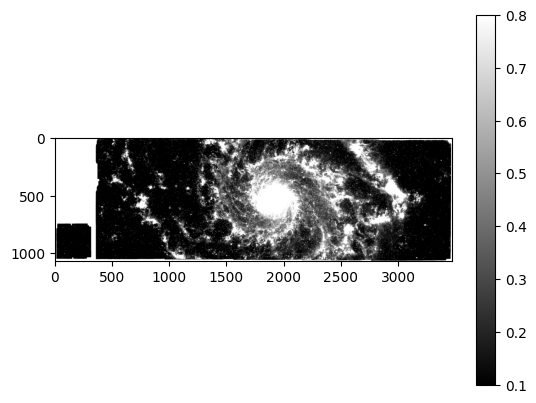

In [ ]:
build_datasets(fits_path, catalogue_path, out_bubblemask=out_bubblemask, fix_radius=False, filter_small_bubbles=20)


Set DATE-AVG to '2023-01-15T10:26:26.672' from MJD-AVG.
Set DATE-END to '2023-01-15T12:15:51.322' from MJD-END'. [astropy.wcs.wcs]
Set DATE-AVG to '2023-01-15T10:26:26.672' from MJD-AVG.
Set DATE-END to '2023-01-15T12:15:51.322' from MJD-END'.
Set OBSGEO-B to     7.899584 from OBSGEO-[XYZ].
Set OBSGEO-H to 1682928111.612 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to     7.899584 from OBSGEO-[XYZ].
Set OBSGEO-H to 1682928111.612 from OBSGEO-[XYZ]'.


<class 'numpy.ndarray'>
(1073, 3469)
   ID       RA_DMS      DEC_DMS  SEMI_MAJ_PC  SEMI_MIN_PC  AVG_RAD_PC  PA_DEG  \
0   1  24d08m55.9s   15d48m7.9s           86           86          86       0   
1   2  24d08m56.7s   15d48m2.9s           24           24          24       0   
2   3  24d08m57.0s   15d48m9.0s           42           42          42       0   
3   4  24d08m58.0s  15d47m44.9s           25           25          25       0   
4   5  24d08m58.2s   15d48m2.6s           24           24          24       0   

   ARM  DIST_ARM_PC  GAL_RAD_KPC  
0    3          145         5.22  
1    3          127         5.05  
2    3          138         5.21  
3    3          101         4.54  
4    3          114         4.98  
Index(['ID', 'RA_DMS', 'DEC_DMS', 'SEMI_MAJ_PC', 'SEMI_MIN_PC', 'AVG_RAD_PC',
       'PA_DEG', 'ARM', 'DIST_ARM_PC', 'GAL_RAD_KPC'],
      dtype='object')
(1694, 10)


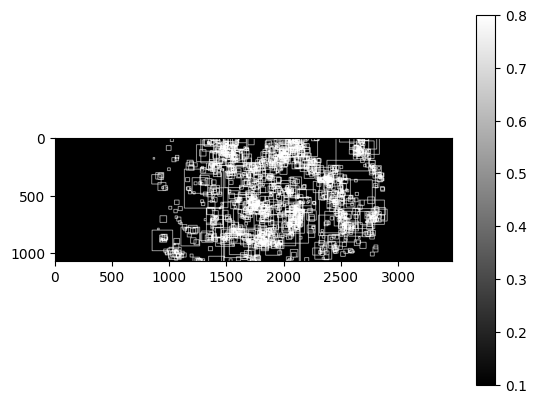

In [ ]:
image_data, wcs = load_galaxy_image(fits_path)
df = load_catalogue(catalogue_path)
is_fill = False
set_thickness = 2

regions = make_bubble_mask(df, wcs, image_data.shape)
mask = np.zeros(image_data.shape[:2], dtype=np.uint8)

if is_fill:
  set_thickness = -1

for region in regions:
        cx, cy = region["center"]
        r = region["radius"]

        # Define rectangle coordinates
        x1, y1 = int(cx - r), int(cy - r)
        x2, y2 = int(cx + r), int(cy + r)

        # Draw a white rectangle (value 255)
        cv2.rectangle(mask, (x1, y1), (x2, y2), 255, thickness=set_thickness)

plt.imshow(mask, cmap=const_cmap)
save_files("ngc628_binarymask", file_type='.jpg', path=out_bubblemask)


In [ ]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from astropy.io import fits
import cv2
from torchvision import transforms as T
import matplotlib.pyplot as plt

def load_fits_image(fits_path):
    h = fits.open(fits_path)
    data = h[0].data.astype(np.float32)
    h.close()
    # If data is 2D but maybe has extra dims, take first 2D
    if data.ndim > 2:
        # collapse channels/axes if needed, otherwise take first slice
        data = data.squeeze()
        if data.ndim > 2:
            data = data[0]
    # Normalize to 0-255 for visualization and model stability
    data = data - np.nanmin(data)
    if np.nanmax(data) > 0:
        data = data / np.nanmax(data)
    data = (data * 255).astype(np.uint8)
    return data

def regions_to_boxes(regions, image_shape):
    h, w = image_shape[:2]
    boxes = []
    for reg in regions:
        cx, cy = reg["center"]
        r = reg["radius"]
        x1 = int(np.clip(cx - r, 0, w-1))
        y1 = int(np.clip(cy - r, 0, h-1))
        x2 = int(np.clip(cx + r, 0, w-1))
        y2 = int(np.clip(cy + r, 0, h-1))
        # ensure non-zero area
        if x2 > x1 and y2 > y1:
            boxes.append([x1, y1, x2, y2])
    return boxes

def collate_fn(batch):
    return tuple(zip(*batch))


In [ ]:
import pandas as pd
from astropy.wcs import WCS

class FitsBubbleDataset(Dataset):
    def __init__(self, images_dir, annotations_df, transforms=None, make_mask_fn=None):
        self.images_dir = images_dir
        self.annotations_df = annotations_df
        self.transforms = transforms
        self.make_mask_fn = make_mask_fn or (lambda df, wcs, shape, is_binary: ([], None))
        self.image_ids = sorted(self.annotations_df['ID'].unique())

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        # assume file name = f"{img_id}.fits"
        img_path = os.path.join(self.images_dir, f"{img_id}.fits")

        image = load_fits_image(img_path)

        try:
            hdr = fits.getheader(img_path)
            wcs = WCS(hdr)
        except Exception:
            wcs = None

        # subset rows for this ID
        df_img = self.annotations_df[self.annotations_df['ID'] == img_id].reset_index(drop=True)

        regions = []
        if wcs is not None:
            for _, row in df_img.iterrows():
                coord = get_coord(row['RA_DMS'], row['DEC_DMS'], unit=(u.deg, u.deg))
                x, y = wcs.world_to_pixel(coord)
                r = pc_to_px(row['AVG_RAD_PC'], wcs)
                regions.append({"center": (x, y), "radius": r})
        else:
            # fallback to pixel coordinates if present
            for _, row in df_img.iterrows():
                x = float(row.get('x', np.nan))
                y = float(row.get('y', np.nan))
                r = float(row.get('radius_px', np.nan))
                regions.append({"center": (x, y), "radius": r})

        boxes = regions_to_boxes(regions, image.shape)
        num_boxes = len(boxes)

        boxes_tensor = torch.as_tensor(boxes, dtype=torch.float32) if num_boxes else torch.zeros((0, 4), dtype=torch.float32)
        labels = torch.ones((num_boxes,), dtype=torch.int64)
        image_id_tensor = torch.tensor([idx])
        area = (boxes_tensor[:, 3] - boxes_tensor[:, 1]) * (boxes_tensor[:, 2] - boxes_tensor[:, 0]) if num_boxes else torch.zeros((0,), dtype=torch.float32)
        iscrowd = torch.zeros((num_boxes,), dtype=torch.int64)

        target = {
            "boxes": boxes_tensor,
            "labels": labels,
            "image_id": image_id_tensor,
            "area": area,
            "iscrowd": iscrowd
        }

        img_3c = np.stack([image, image, image], axis=-1)
        img_tensor = torch.from_numpy(img_3c).permute(2, 0, 1).float() / 255.0

        if self.transforms:
            img_tensor = self.transforms(img_tensor)

        return img_tensor, target


In [ ]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def get_fasterrcnn_model(num_classes=2):  # background + bubble
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
    # replace head predictor
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


In [ ]:
import torch
import torch.optim as optim
from tqdm import tqdm

def train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=50):
    model.train()
    running_loss = 0.0
    for i, (images, targets) in enumerate(tqdm(data_loader)):
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k,v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        running_loss += losses.item()
        if (i+1) % print_freq == 0:
            print(f"Epoch {epoch} Iter {i+1} avg_loss {running_loss/(i+1):.4f}")

    return running_loss / len(data_loader)

@torch.no_grad()
def evaluate(model, data_loader, device):
    model.eval()
    # Very simple metric: detection count and inspect losses not available in eval mode
    total = 0
    detected = 0
    for images, targets in data_loader:
        images = [img.to(device) for img in images]
        outputs = model(images)
        for out, tgt in zip(outputs, targets):
            # count predicted boxes with score > 0.5
            pred_boxes = out.get("boxes", torch.zeros((0,4))).cpu().numpy()
            scores = out.get("scores", torch.zeros((0,)))
            detected += (scores > 0.5).sum().item()
            total += len(tgt["boxes"])
    print("Eval: total gt boxes:", total, "predicted (score>0.5):", detected)
    return {"total_gt": total, "predicted": detected}

In [ ]:
# Paths and CSV
images_dir = root_path   # fits folder in Colab
annotations_csv = catalogue_path  # with ID and RA/DEC/AVG_RAD_PC or pixel coords
annotations_df = pd.read_csv(annotations_csv)

# dataset, split
full_ds = FitsBubbleDataset(images_dir, annotations_df, transforms=None)
train_size = int(0.8 * len(full_ds))
val_size = len(full_ds) - train_size
train_ds, val_ds = random_split(full_ds, [train_size, val_size])

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model = get_fasterrcnn_model(num_classes=2)
model.to(device)

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, collate_fn=collate_fn)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

num_epochs = 10
for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, optimizer, train_loader, device, epoch)
    print(f"Epoch {epoch} finished. Train loss: {train_loss:.4f}")
    lr_scheduler.step()
    evaluate(model, val_loader, device)

# Save model weights
torch.save(model.state_dict(), "/content/drive/MyDrive/thesisDocuments/fasterrcnn_bubbles.pth")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
  0%|          | 0/678 [00:00<?, ?it/s]


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/thesisDocuments/11.fits'